### Time to synthesise some data

We want to fit a model based on the Poisson Pseudo Maximum Likelihood method to model the data (this is good for heteroskedastic data)

Then we can use this to compute synthetic trade data (that will lack outliers)

In [ ]:
# First we got to do some imports (I'm just grabbing the ones from 02 for now)
from pathlib import Path
import platform
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

def synthetic_trade_generator(target_variable: str, df: pd.DataFrame, min_value:float = 0.0, printing_state:bool = True) -> pd.DataFrame:
    '''
    Function for creating a synthetic trade column, using gdp and weighted distance parameters.

    input:
        target_variable = string for the column string name which we are working from
        df = pandas DataFrame on which we are doing the work
        min_value = float for minimum value that gets overwritten with a synthetic value

    output:
        df_synthetic = pandas DataFrame with updated columns for missing trade, and new columns for synthetic flags. 
    '''
    df_work = df.copy()

    required_cols = ["gdp_o", "gdp_d", "distw_arithmetic", "contig", "comlang_off", "comlang_ethno", target_variable]

    df_work = df_work[required_cols].dropna()
    df_work = df_work[
        (df_work["gdp_o"] > 0) &
        (df_work["gdp_d"] > 0) &
        (df_work["distw_arithmetic"] > 0) &
        (df_work[f"{target_variable}"] >= 0)
    ]

    df_work["ln_gdp_o"] = np.log(df_work["gdp_o"])
    df_work["ln_gdp_d"] = np.log(df_work["gdp_d"])
    df_work["ln_distw_arithmetic"] = np.log(df_work["distw_arithmetic"])


    X = sm.add_constant(df_work[["ln_gdp_o", "ln_gdp_d", "ln_distw_arithmetic", "contig", "comlang_off", "comlang_ethno"]])
    y = df_work[f"{target_variable}"]

    # Sanity check just in case
    assert np.isfinite(X.values).all()
    assert np.isfinite(y.values).all()

    ppml = sm.GLM(
        y,
        X,
        family=sm.families.Poisson()
    )
    ppml_results = ppml.fit(cov_type="HC1")
    
    # Done training the model on the data we have!
    # Now to create the synthetic data from the ppml
    # This is done by sampling with some variance. 

    # First we find the target values that are missing.

    df_work = df.copy()
    missing_mask = (
        (df_work[f"{target_variable}"].isna() | (df_work[target_variable] < min_value)) &
        (df_work["gdp_o"] > 0) &
        (df_work["gdp_d"] > 0) &
        (df_work["distw_arithmetic"] > 0)
    )

    df_work_missing = df_work.loc[missing_mask].copy()

    df_work_missing["ln_gdp_o"] = np.log(df_work_missing["gdp_o"])
    df_work_missing["ln_gdp_d"] = np.log(df_work_missing["gdp_d"])
    df_work_missing["ln_distw_arithmetic"] = np.log(df_work_missing["distw_arithmetic"])

    X_missing = sm.add_constant(
        df_work_missing[["ln_gdp_o", "ln_gdp_d", "ln_distw_arithmetic", "contig", "comlang_off", "comlang_ethno"]]
    )

    assert np.isfinite(X_missing.values).all()


    # After this we can predict mu-hat --->> This is the conditional mean trade flow (so based on these variables, the expected trade) 
    mu_hat = ppml_results.predict(X_missing)


    # Now we can generate the synthetic trade flows:
    synthetic_trade = np.random.poisson(mu_hat)
    # PPML assumes Poisson conditional mean
    # This preserves zero probability
    # This preserves scale heteroskedasticity
    if printing_state:
        print(f"Amount of rows updated for {target_variable} and threshold {min_value}: {missing_mask.sum()}")


    df_synthetic = df.copy()
    #df_synthetic[f"{target_variable}_synthetic_flag"] = 0

    df_synthetic.loc[missing_mask, f"{target_variable}"] = synthetic_trade
    df_synthetic.loc[missing_mask, f"{target_variable}_synthetic_flag"] = 1
    df_synthetic.loc[~missing_mask, f"{target_variable}_synthetic_flag"] = 0

    return df_synthetic

def synthetic_data_info(list_of_columns:list, df: pd.DataFrame):
    '''
    Function for seeing various information about the changed columns.

    input:
        list_of_columns = A list of strings for column names that have been changed
        df = pandas dataframe with synthetic data generated by the synthetic_trade_generator
    output:

    '''

    descr = []

    for i in list_of_columns:
        syn_flag = f"{i}_synthetic_flag"


        temp_desc = (df.groupby(syn_flag)[i].describe().assign(variable=i))

        descr.append(temp_desc)

    resulting_descr = pd.concat(descr)

    for i in list_of_columns:
        plt.hist(
            df.loc[df[f"{i}_synthetic_flag"] == 0, i],
            bins=50, alpha=0.6, label="Observed"
        )
        plt.hist(
            df.loc[df[f"{i}_synthetic_flag"] == 1, i],
            bins=50, alpha=0.6, label="Synthetic"
        )
        plt.legend()
        plt.title(i)
        plt.show()

    
    return resulting_descr

def main(set_random_state:int = 42, printing_state:bool = True):
    '''
    Calling all functions for synthetic datasets to update the 3 initial dataframes.
    '''
    # Random seed for reproducibility
    np.random.seed(set_random_state)
    Path("data/synth").mkdir(parents=True, exist_ok=True)

    # For all 3 lag times...
    df_zero = pd.read_csv("data/ecowas_df_full_lag_zero.csv")
    df_one = pd.read_csv("data/ecowas_df_full_lag_one.csv")
    df_two = pd.read_csv("data/ecowas_df_full_lag_two.csv")

    df_list = [df_zero, df_one, df_two]
    names = ["zero", "one", "two"]
    threshold = [0, 10, 100]


    columns_to_update = ['tradeflow_baci', 'tradeflow_comtrade_o', 'tradeflow_comtrade_d', 'tradeflow_imf_o', 'tradeflow_imf_d']

    for thresh in threshold:
        for name, df in zip(names, df_list):
            df_update = df.copy()

            for col in columns_to_update:
                df_update = synthetic_trade_generator(col, df_update, thresh, printing_state)

            #statistics_synth = synthetic_data_info(columns_to_update, df_update)
            #print(statistics_synth)

            # Before we save to csv, we need to update the combined_trade column, as tradeflow_baci only deals in exports
            # Then we can aggregate total trade per dyad for each year
            df_update = df_update.drop(columns=["combined_trade_baci"], errors="ignore")
            combined = (
                df_update.groupby(["dyad", "year"])["tradeflow_baci"]
                .sum()
                .reset_index()
                .rename(columns={"tradeflow_baci": "combined_trade_baci"})
            )

            # And we tack this onto the end of our dataframe. Our new column "combined_trade" can now be used
            df_update = df_update.merge(combined, on=["dyad", "year"], how="left")

            df_update.to_csv(f"data/synth/ecowas_df_synthetic_full_lag_{name}_{thresh}.csv", index=False)


In [6]:
main()

Amount of rows updated for tradeflow_baci: 1040
Amount of rows updated for tradeflow_comtrade_o: 1645
Amount of rows updated for tradeflow_comtrade_d: 1613
Amount of rows updated for tradeflow_imf_o: 1108
Amount of rows updated for tradeflow_imf_d: 962
Amount of rows updated for tradeflow_baci: 900
Amount of rows updated for tradeflow_comtrade_o: 1584
Amount of rows updated for tradeflow_comtrade_d: 1560
Amount of rows updated for tradeflow_imf_o: 1066
Amount of rows updated for tradeflow_imf_d: 931
Amount of rows updated for tradeflow_baci: 837
Amount of rows updated for tradeflow_comtrade_o: 1524
Amount of rows updated for tradeflow_comtrade_d: 1496
Amount of rows updated for tradeflow_imf_o: 1021
Amount of rows updated for tradeflow_imf_d: 890
Amount of rows updated for tradeflow_baci: 1287
Amount of rows updated for tradeflow_comtrade_o: 1835
Amount of rows updated for tradeflow_comtrade_d: 1861
Amount of rows updated for tradeflow_imf_o: 1387
Amount of rows updated for tradeflow_i

In [4]:
# First we got to do some imports (I'm just grabbing the ones from 02 for now)
from pathlib import Path
import platform
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Random seed for reproducibility
np.random.seed(42)


df = pd.read_csv("data/ecowas_df_full.csv")

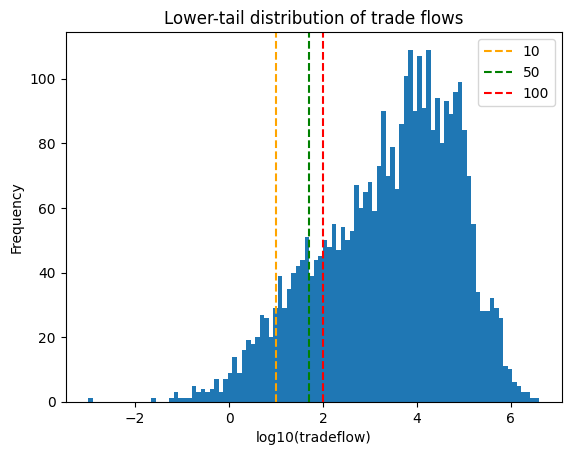

In [5]:

low_tail = df[df["tradeflow_baci"] > 0]["tradeflow_baci"]

plt.hist(np.log10(low_tail), bins=100)
plt.axvline(np.log10(10), color="orange", linestyle="--", label="10")
plt.axvline(np.log10(50), color="green", linestyle="--", label="50")
plt.axvline(np.log10(100), color="red", linestyle="--", label="100")
plt.legend()
plt.xlabel("log10(tradeflow)")
plt.ylabel("Frequency")
plt.title("Lower-tail distribution of trade flows")
plt.show()

In [2]:
df.columns

Index(['country', 'year', 'disorder_Demonstrations',
       'disorder_Political violence',
       'disorder_Political violence; Demonstrations',
       'disorder_Strategic developments', 'event_Battles',
       'event_Explosions/Remote violence', 'event_Protests', 'event_Riots',
       'event_Strategic developments', 'event_Violence against civilians',
       'perpetrator_Civilians', 'perpetrator_External/Other forces',
       'perpetrator_Identity militia', 'perpetrator_Political militia',
       'perpetrator_Protesters', 'perpetrator_Rebel group',
       'perpetrator_Rioters', 'perpetrator_State forces', 'target_Civilians',
       'target_External/Other forces', 'target_Identity militia',
       'target_Political militia', 'target_Protesters', 'target_Rebel group',
       'target_Rioters', 'target_State forces', 'fatalities', 'iso3_o',
       'iso3_d', 'distw_harmonic', 'distw_arithmetic', 'dist', 'distcap',
       'contig', 'diplo_disagreement', 'comlang_off', 'comlang_ethno',
     

In [10]:
def synthetic_trade_generator(target_variable: str, df: pd.DataFrame, random_state = 42) -> pd.DataFrame:
    '''
    Function for creating a synthetic trade column, using gdp and weighted distance parameters.

    Input:
        target_variable: string - 
            The column string name which we are working from
        df: pd DataFrame - 
            a DataFrame on which we are doing the work

    Output:
        synethic_df: pd.DataFrame - 
            An updated dataframe with updated columns for missing trade, and new columns for synthetic flags. 
    '''

    np.random.seed(random_state)
    MIN_VALUE = 0.0 # Values below this will also be synthetically created.


    df_work = df.copy()

    required_cols = ["gdp_o", "gdp_d", "distw_arithmetic", "contig", "comlang_off", "comlang_ethno", target_variable]

    df_work = df_work[required_cols].dropna()
    df_work = df_work[
        (df_work["gdp_o"] > 0) &
        (df_work["gdp_d"] > 0) &
        (df_work["distw_arithmetic"] > 0) &
        (df_work[f"{target_variable}"] >= 0)
    ]

    df_work["ln_gdp_o"] = np.log(df_work["gdp_o"])
    df_work["ln_gdp_d"] = np.log(df_work["gdp_d"])
    df_work["ln_distw_arithmetic"] = np.log(df_work["distw_arithmetic"])


    X = sm.add_constant(df_work[["ln_gdp_o", "ln_gdp_d", "ln_distw_arithmetic", "contig", "comlang_off", "comlang_ethno"]])
    y = df_work[f"{target_variable}"]

    # Sanity check just in case
    assert np.isfinite(X.values).all()
    assert np.isfinite(y.values).all()

    ppml = sm.GLM(
        y,
        X,
        family=sm.families.Poisson()
    )
    ppml_results = ppml.fit(cov_type="HC1")
    
    # Done training the model on the data we have!
    # Now to create the synthetic data from the ppml
    # This is done by sampling with some variance. 

    # First we find the target values that are missing.

    df_work = df.copy()
    missing_mask = (
        (df_work[f"{target_variable}"].isna() | (df_work[target_variable] < MIN_VALUE)) &
        (df_work["gdp_o"] > 0) &
        (df_work["gdp_d"] > 0) &
        (df_work["distw_arithmetic"] > 0)
    )

    df_work_missing = df_work.loc[missing_mask].copy()

    df_work_missing["ln_gdp_o"] = np.log(df_work_missing["gdp_o"])
    df_work_missing["ln_gdp_d"] = np.log(df_work_missing["gdp_d"])
    df_work_missing["ln_distw_arithmetic"] = np.log(df_work_missing["distw_arithmetic"])

    X_missing = sm.add_constant(
        df_work_missing[["ln_gdp_o", "ln_gdp_d", "ln_distw_arithmetic", "contig", "comlang_off", "comlang_ethno"]]
    )

    assert np.isfinite(X_missing.values).all()


    # After this we can predict mu-hat --->> This is the conditional mean trade flow (so based on these variables, the expected trade) 
    mu_hat = ppml_results.predict(X_missing)


    # Now we can generate the synthetic trade flows:
    synthetic_trade = np.random.poisson(mu_hat)
    # PPML assumes Poisson conditional mean
    # This preserves zero probability
    # This preserves scale heteroskedasticity
    print(f"Amount of rows updated for {target_variable}: {missing_mask.sum()}")


    df_synthetic = df.copy()
#    df_synthetic[f"{target_variable}_synthetic_flag"] = 0

    df_synthetic.loc[missing_mask, f"{target_variable}"] = synthetic_trade
    df_synthetic.loc[missing_mask, f"{target_variable}_synthetic_flag"] = 1
    df_synthetic.loc[~missing_mask, f"{target_variable}_synthetic_flag"] = 0

    return df_synthetic

def synthetic_data_info(list_of_columns:list, df: pd.DataFrame):
    '''
    Function for seeing various information about the changed columns.

    Input:
        list_of_columns: list -
            A list of strings for column names that have been changed
        df: pd.DataFrame -
            The dataframe with synthetic data generated by the synthetic_trade_generator
    '''

    descr = []

    for i in list_of_columns:
        syn_flag = f"{i}_synthetic_flag"


        temp_desc = (df.groupby(syn_flag)[i].describe().assign(variable=i))

        descr.append(temp_desc)

    resulting_descr = pd.concat(descr)

    for i in list_of_columns:
        plt.hist(
            df.loc[df[f"{i}_synthetic_flag"] == 0, i],
            bins=50, alpha=0.6, label="Observed"
        )
        plt.hist(
            df.loc[df[f"{i}_synthetic_flag"] == 1, i],
            bins=50, alpha=0.6, label="Synthetic"
        )
        plt.legend()
        plt.title(i)
        plt.show()


    

    return resulting_descr


Amount of rows updated for tradeflow_baci: 900
Amount of rows updated for tradeflow_comtrade_o: 1584
Amount of rows updated for tradeflow_comtrade_d: 1560
Amount of rows updated for tradeflow_imf_o: 1066
Amount of rows updated for tradeflow_imf_d: 931


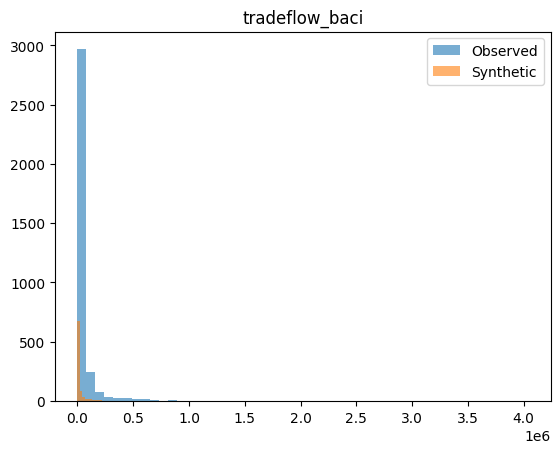

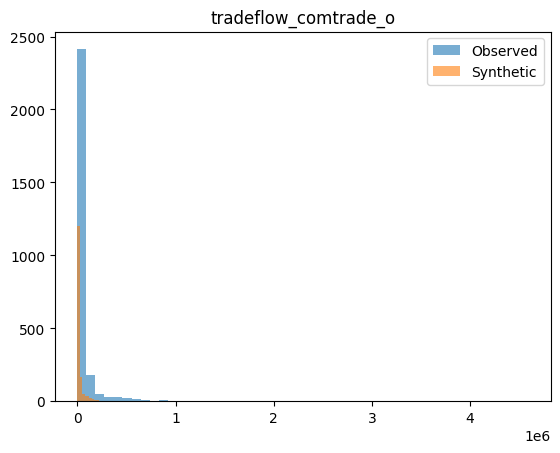

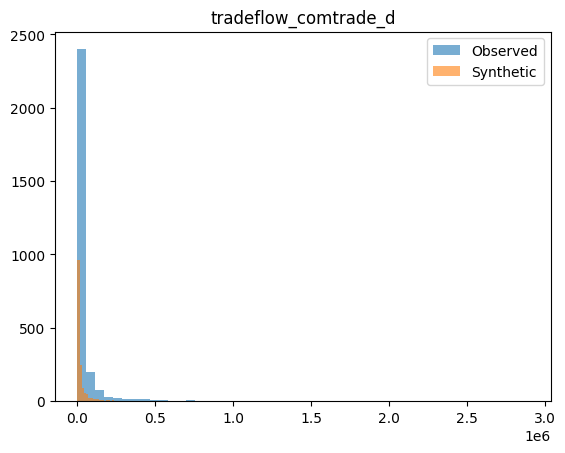

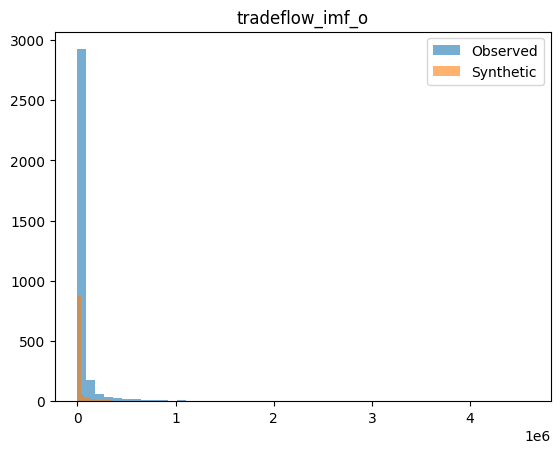

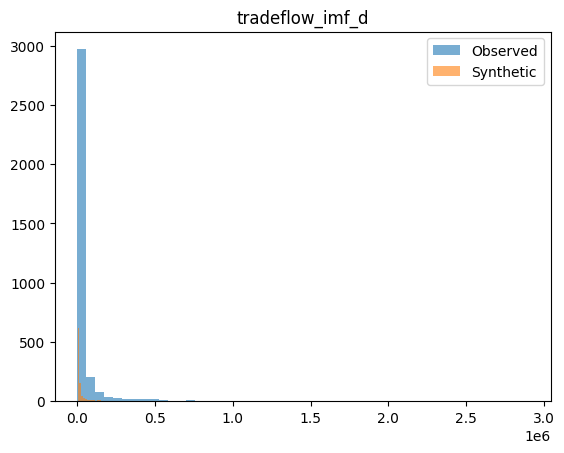

      count          mean            std      min         25%        50%  \
0.0  3468.0  53371.897513  180197.642337    0.001   249.12175  4606.6995   
1.0   900.0  33482.128889   89437.479241  494.000  3125.25000  6993.5000   
0.0  2784.0  60696.137166  212988.757642    0.001   399.19800  5415.5890   
1.0  1584.0  30021.969066   77128.022440  460.000  3041.00000  7167.5000   
0.0  2808.0  43222.873917  164404.240620    0.012   155.25525  2421.6940   
1.0  1560.0  30429.937821   63811.090822  507.000  3971.75000  9629.0000   
0.0  3302.0  55211.314895  201807.339788    0.003   301.05950  3925.5815   
1.0  1066.0  36661.455910  102412.955057  242.000  1968.00000  4520.0000   
0.0  3437.0  42977.797893  157813.242245    0.012   185.68300  2582.5730   
1.0   931.0  24479.636950   55101.989960  758.000  4221.50000  8099.0000   

             75%          max              variable  
0.0  32466.31325  4041932.750        tradeflow_baci  
1.0  21996.00000  1084502.000        tradeflow_baci  
0

In [11]:
columns_to_update = ['tradeflow_baci', 'tradeflow_comtrade_o', 'tradeflow_comtrade_d', 'tradeflow_imf_o', 'tradeflow_imf_d']

df_update = df

for i in columns_to_update:
    df_update = synthetic_trade_generator(i, df_update)

statistics_synth = synthetic_data_info(columns_to_update, df_update)
print(statistics_synth)

In [12]:
# Before we save to csv, we need to update the combined_trade column, as tradeflow_baci only deals in exports

# Then we can aggregate total trade per dyad for each year
combined = (
    df_update.groupby(["dyad", "year"])["tradeflow_baci"]
      .sum()
      .reset_index()
      .rename(columns={"tradeflow_baci": "combined_trade_baci"})
)

# And we tack this onto the end of our dataframe. Our new column "combined_trade" can now be used
df_update = df_update.merge(combined, on=["dyad", "year"], how="left")


df_update.to_csv("data/ecowas_df_synthetic_full.csv")

### Synthetise the entire dataset

Let us assume trade overall follows the observed structural pattern, and let's draw from this too.

Crucially, we consider all observed trade data as a noisy, partial, and censored snapshot of a smoother underlying trading system


What distribution are we drawing from though? Poisson is very tight around the mean, so we could try the negative binomial or gamma poisson

In [16]:
testing = ["hello", "test", "here"]

for i, j in enumerate(testing):
    name_file = f"list_test{i}"
    name_file = list(name_file)
    name_file.append(i)
    print(name_file)

['l', 'i', 's', 't', '_', 't', 'e', 's', 't', '0', 0]
['l', 'i', 's', 't', '_', 't', 'e', 's', 't', '1', 1]
['l', 'i', 's', 't', '_', 't', 'e', 's', 't', '2', 2]


In [40]:
def big_synth_df(df: pd.DataFrame, random_state = 42):
    '''
    A central function for finding the conditional means of the trade flows present in the data by estimating Gravity on the raw observed data, 
    then constructing a full dyadic matrix, predicting mu-hat for all dyads and drawing samples from a new distribution fitted on top



    '''
    target_variables = ['tradeflow_baci', 'tradeflow_comtrade_o', 'tradeflow_comtrade_d', 'tradeflow_imf_o', 'tradeflow_imf_d']

    model_results = {}

    np.random.seed(random_state)


    for i, target_variable in enumerate(target_variables):
        
        # We get a fresh dataframe and check for input
        df_work = df.copy()
        required_cols = ["gdp_o", "gdp_d", "dist", "contig", target_variable]

        df_work = df_work[required_cols].dropna()
        df_work = df_work[
            (df_work["gdp_o"] > 0) &
            (df_work["gdp_d"] > 0) &
            (df_work["dist"] > 0) &
            (df_work[f"{target_variable}"] >= 0)
        ]

        df_work["ln_gdp_o"] = np.log(df_work["gdp_o"])
        df_work["ln_gdp_d"] = np.log(df_work["gdp_d"])
        df_work["ln_dist"] = np.log(df_work["dist"])


        X = sm.add_constant(df_work[["ln_gdp_o", "ln_gdp_d", "ln_dist", "contig"]])
        y = df_work[f"{target_variable}"]

        # Sanity check just in case
        assert np.isfinite(X.values).all()
        assert np.isfinite(y.values).all()

        model = sm.GLM(
            y,
            X,
            family=sm.families.Poisson()
        )
        results = model.fit(cov_type="HC1")

        model_results[target_variable] = {
            "results": results,
            "design_matrix_cols": X.columns.tolist(),
            "n_obs": len(df_work),
        }

    return model_results


def construct_dyad_matrix(df: pd.DataFrame):
    '''
    Function for creating a matrix


    '''

    # We first need to save info on the exporters and importers, that will be the rows and columns
    exporters = (
        df[["iso3_o", "year", "gdp_o"]]
        .dropna()
        .drop_duplicates()
        .rename(columns={"iso3_o": "exporter", "gdp_o": "gdp_exporter"})
    )

    importers = (
        df[["iso3_d", "year", "gdp_d"]]
        .dropna()
        .drop_duplicates()
        .rename(columns={"iso3_d": "importer", "gdp_d": "gdp_importer"})
    )

    # We find the Cartesian product within each year
    exporters["key"] = 1
    importers["key"] = 1
    dyads = exporters.merge(importers, on=["year", "key"]).drop("key", axis=1)
    # Remove intra-national trade (we are only interested in the international kind)
    dyads = dyads[dyads["exporter"] != dyads["importer"]]

    # We merge the bilaterals
    bilateral_vars = (
        df[
            [
                "iso3_o",
                "iso3_d",
                "dist",
                "contig",
            ]
        ]
        .dropna()
        .drop_duplicates()
        .rename(
            columns={
                "iso3_o": "exporter",
                "iso3_d": "importer",
            }
        )
    )

    dyads = dyads.merge(
        bilateral_vars,
        on=["exporter", "importer"],
        how="left",
    )

    return dyads


def add_gravity_transforms(dyads: pd.DataFrame) -> pd.DataFrame:
    '''
    Tiny function for adding the log variables to keep consistency for mu_hat approximation. 
    '''
    dyads = dyads.copy()

    dyads["ln_gdp_o"] = np.log(dyads["gdp_exporter"])
    dyads["ln_gdp_d"] = np.log(dyads["gdp_importer"])
    dyads["ln_dist"] = np.log(dyads["dist"])

    return dyads



def mu_hat_predictor(df: pd.DataFrame, model_results: dict):
    '''
    Takes the input from previous two functions to compute the mu_hat values

    '''
    dyads = df.copy()

    for target_variable, model_info in model_results.items():
        results = model_info["results"]
        design_cols = model_info["design_matrix_cols"]

        # We build the X_full using the same regressors as when we're doing estimation
        X_full = sm.add_constant(
            dyads[[col for col in design_cols if col != "const"]],
            has_constant="add",
        )

        mu_hat = results.predict(X_full)

        dyads[f"mu_hat_{target_variable}"] = mu_hat

    return dyads

    

In [43]:
print(dyad_matrix.head(15))

   exporter  year  gdp_exporter importer  gdp_importer    dist  contig  \
0       BEN  1998   2455092.736      BFA  2.804902e+06   793.0     1.0   
1       BEN  1998   2455092.736      BFA  2.804902e+06   782.0     1.0   
2       BEN  1998   2455092.736      CIV  1.278257e+07   723.0     0.0   
3       BEN  1998   2455092.736      CIV  1.278257e+07   717.0     0.0   
4       BEN  1998   2455092.736      GHA  7.482073e+06   303.0     0.0   
5       BEN  1998   2455092.736      GHA  7.482073e+06   441.0     0.0   
6       BEN  1998   2455092.736      GIN  3.588376e+06  1806.0     0.0   
7       BEN  1998   2455092.736      GIN  3.588376e+06  1797.0     0.0   
8       BEN  1998   2455092.736      GMB  8.402852e+05  2235.0     0.0   
9       BEN  1998   2455092.736      GMB  8.402852e+05  2225.0     0.0   
10      BEN  1998   2455092.736      GNB  2.064576e+05  2071.0     0.0   
11      BEN  1998   2455092.736      GNB  2.064576e+05  2061.0     0.0   
12      BEN  1998   2455092.736      L

In [41]:
model_results = big_synth_df(df)
dyad_matrix = construct_dyad_matrix(df)
dyad_matrix = add_gravity_transforms(dyad_matrix)

mu_hat_df = mu_hat_predictor(dyad_matrix, model_results)

model_results

{'tradeflow_baci': {'results': <statsmodels.genmod.generalized_linear_model.GLMResultsWrapper at 0x19306b32e50>,
  'design_matrix_cols': ['const', 'ln_gdp_o', 'ln_gdp_d', 'ln_dist', 'contig'],
  'n_obs': 3468},
 'tradeflow_comtrade_o': {'results': <statsmodels.genmod.generalized_linear_model.GLMResultsWrapper at 0x19306b79550>,
  'design_matrix_cols': ['const', 'ln_gdp_o', 'ln_gdp_d', 'ln_dist', 'contig'],
  'n_obs': 2784},
 'tradeflow_comtrade_d': {'results': <statsmodels.genmod.generalized_linear_model.GLMResultsWrapper at 0x19307167cd0>,
  'design_matrix_cols': ['const', 'ln_gdp_o', 'ln_gdp_d', 'ln_dist', 'contig'],
  'n_obs': 2808},
 'tradeflow_imf_o': {'results': <statsmodels.genmod.generalized_linear_model.GLMResultsWrapper at 0x193071657d0>,
  'design_matrix_cols': ['const', 'ln_gdp_o', 'ln_gdp_d', 'ln_dist', 'contig'],
  'n_obs': 3302},
 'tradeflow_imf_d': {'results': <statsmodels.genmod.generalized_linear_model.GLMResultsWrapper at 0x19306ffb9d0>,
  'design_matrix_cols': ['con

### Below is the WIP for creating the synthesiser

Kept since it works!

In [13]:
df_benin = df[df["country"] == "Benin"].copy()
# Since we are dealing with least squares, we can log the valid variables to get changes in %, rather than absolute values (also good as trade is heteroskedastic)
# This is the standard when dealing with the Gravity theory of trade
# However, we can not have values that are 0, since that leads to -inf or NaN 

required_cols = ["gdp_o", "gdp_d", "distw_arithmetic", "tradeflow_baci", "contig"]

df_benin = df_benin[required_cols].dropna()
df_benin = df_benin[
    (df_benin["gdp_o"] > 0) &
    (df_benin["gdp_d"] > 0) &
    (df_benin["distw_arithmetic"] > 0) &
    (df_benin["tradeflow_baci"] >= 0)
]


df_benin["ln_gdp_o"] = np.log(df_benin["gdp_o"])
df_benin["ln_gdp_d"] = np.log(df_benin["gdp_d"])
df_benin["ln_distw_arithmetic"] = np.log(df_benin["distw_arithmetic"])

# Variables that are statistically significant here are gdpcap_ppp_o, gdp_o, pop_d
X = sm.add_constant(df_benin[["ln_gdp_o", "ln_gdp_d", "ln_distw_arithmetic", "contig"]])
y = df_benin["tradeflow_baci"]

# We can add a little sanity check here (will be useful in the future python implementation)
assert np.isfinite(X.values).all()
assert np.isfinite(y.values).all()

ppml = sm.GLM(
    y,
    X,
    family=sm.families.Poisson()
)
ppml_results = ppml.fit(cov_type="HC1")

print(ppml_results.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:         tradeflow_baci   No. Observations:                  272
Model:                            GLM   Df Residuals:                      267
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.4162e+06
Date:                Thu, 23 Apr 2026   Deviance:                   1.0830e+07
Time:                        20:56:13   Pearson chi2:                 4.64e+07
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:                  HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.0527    

In [4]:
# An example from the data above. We can take the coefficient for the "contig" column and use the PPML formula to find the percentile effect of sharing borders
np.exp(0.8216) - 1

# In this case = 1.27 == 127%

np.float64(1.2741355450628644)

In [ ]:
# Now we want to create synthetic data from the PPML. We must make a mask where the tradeflow_baci is missing, but we have valid covariates (those being gdp and distw at the moment)
df_benin_full = df[df["country"] == "Benin"].copy()


missing_mask = (
    df_benin_full["tradeflow_baci"].isna() &
    (df_benin_full["gdp_o"] > 0) &
    (df_benin_full["gdp_d"] > 0) &
    (df_benin_full["distw_arithmetic"] > 0)
)

df_benin_missing = df_benin_full.loc[missing_mask].copy()

df_benin_missing["ln_gdp_o"] = np.log(df_benin_missing["gdp_o"])
df_benin_missing["ln_gdp_d"] = np.log(df_benin_missing["gdp_d"])
df_benin_missing["ln_distw_arithmetic"] = np.log(df_benin_missing["distw_arithmetic"])

X_missing = sm.add_constant(
    df_benin_missing[["ln_gdp_o", "ln_gdp_d", "ln_distw_arithmetic", "contig"]]
)

assert np.isfinite(X_missing.values).all()

# After this we can predict mu-hat --->> This is the conditional mean trade flow (so based on these variables, the expected trade) 

mu_hat = ppml_results.predict(X_missing)


# Now we can generate the synthetic trade flows:
synthetic_trade = np.random.poisson(mu_hat)
# PPML assumes Poisson conditional mean
# This preserves zero probability
# This preserves scale heteroskedasticity

df_synthetic = df_benin_full.copy()

df_synthetic.loc[missing_mask, "tradeflow_baci"] = synthetic_trade
df_synthetic.loc[missing_mask, "baci_synthetic_flag"] = 1
df_synthetic.loc[~missing_mask, "baci_synthetic_flag"] = 0


In [6]:
df_synthetic

,country,year,disorder_Demonstrations,disorder_Political violence,disorder_Political violence; Demonstrations,disorder_Strategic developments,event_Battles,event_Explosions/Remote violence,event_Protests,event_Riots,...,gdpcap_ppp_d,tradeflow_baci,manuf_tradeflow_baci,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_imf_o,tradeflow_imf_d,dyad,combined_trade_baci,synthetic_flag
0,Benin,1997,2,0,0,0,0,0,2,0,...,0.733,14749.0,NaN,1008.175,551.155,346.086,560.660,BEN_BFA,0.0,1.0
1,Benin,1997,2,0,0,0,0,0,2,0,...,2.303,11707.0,NaN,2043.770,357.312,1975.433,359.793,BEN_CIV,0.0,1.0
2,Benin,1997,2,0,0,0,0,0,2,0,...,1.619,8041.0,NaN,1746.969,1207.293,260.079,286.087,BEN_GHA,0.0,1.0
3,Benin,1997,2,0,0,0,0,0,2,0,...,0.818,9603.0,NaN,5.133,2.074,5.140,2.716,BEN_GIN,0.0,1.0
4,Benin,1997,2,0,0,0,0,0,2,0,...,1.107,5772.0,NaN,8.580,NaN,25.699,1.274,BEN_GMB,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,Benin,2021,46,101,1,16,18,1,20,79,...,1.310,37255.0,NaN,NaN,NaN,NaN,NaN,BEN_NER,0.0,1.0
321,Benin,2021,46,101,1,16,18,1,20,79,...,5.459,114693.0,NaN,NaN,NaN,NaN,NaN,BEN_NGA,0.0,1.0
322,Benin,2021,46,101,1,16,18,1,20,79,...,3.769,27376.0,NaN,NaN,NaN,NaN,NaN,BEN_SEN,0.0,1.0
323,Benin,2021,46,101,1,16,18,1,20,79,...,1.816,12471.0,NaN,NaN,NaN,NaN,NaN,BEN_SLE,0.0,1.0


In [7]:
df_synthetic.groupby("synthetic_flag")["tradeflow_baci"].describe()

,count,mean,std,min,25%,50%,75%,max
synthetic_flag,,,,,,,,
0.0,273.0,20044.154733,56107.922720,0.207,205.145,5266.101,17758.516,692453.819
1.0,52.0,12866.961538,17037.539387,3415.000,5160.500,7141.000,12252.000,114693.000


In [8]:
observed_mask = df_benin["tradeflow_baci"].notna()

mu_obs = ppml_results.predict(
    sm.add_constant(
        df_benin.loc[observed_mask, ["ln_gdp_o", "ln_gdp_d", "ln_distw_arithmetic", "contig"]]
    )
)

pd.DataFrame({
    "observed": df_benin.loc[observed_mask, "tradeflow_baci"],
    "predicted": mu_obs
}).corr()

,observed,predicted
observed,1.000000,0.369878
predicted,0.369878,1.000000


In [9]:
synthetic_trade

array([ 14749,  11707,   8041,   9603,   5772,   3651,   3493,   7438,
        13399,  35357,   5444,   8607,   3415,   3530,   5003,   4238,
         4307,   4868,   5389,   4332,   4400,   4369,   4346,   6405,
         5193,   7023,   5328,   5063,   6540,   9307,   6344,   6535,
         6813,   6800,   6986,   7563,   7259,  12179,   8724,  40588,
        28531,  26032,  20654,  10192,   9166,  11389,  20250,  37255,
       114693,  27376,  12471,  20965], dtype=int32)

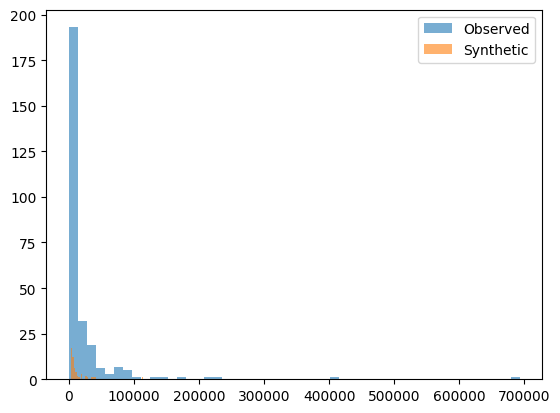

In [10]:

plt.hist(
    df_synthetic.loc[~missing_mask, "tradeflow_baci"],
    bins=50, alpha=0.6, label="Observed"
)
plt.hist(
    df_synthetic.loc[missing_mask, "tradeflow_baci"],
    bins=50, alpha=0.6, label="Synthetic"
)
plt.legend()
plt.show()